# TBMI Assignment 7
_Rijcklof Hofman s4792432_

The code for exercises 6.1 and 6.2 was prepared and ported to Python for you. We discussed
it in class. We will now try to do a number of applications
1. (Preliminary) Modify the code so that it can be called programmatically with different
parameters. Uses your favorite Python approach: classes, nested functions etc (10
points)
2. Experiment with different grid sizes. The program runs quite slowly with an 8x8 grid
(64 sites). Moving to a 6x6 grid, for example, would almost halve the complexity (36
sites) but are the results still sensible (10 points)
3. This Pinto-Ermentrout (modified Wilson-Cowan) system has a large repertoire of
dynamical behaviors. The initial conditions and parameters used in the
Assignment6.ipynb notebook produce rotating waves for example, but that’s only
one possibility. Experiment with different initial conditions and look for stationary
waves, linearly propagating waves, waves propagating from one point and so on. First
try things out in the code from the Assignment6.ipynb notebook, which does not
estimate the Kalman filter so runs faster. When you get something interesting try to apply the Kalman Filter and see if you get it to work. Give at least 3 examples (20
points). Some hints:
a. Use uniform vs. non uniform initial conditions.
b. Create initial conditions using for example 1-D vs 2-D gaussian blobs
c. Try initial conditions with stripes
d. You have to specify both u and a initial conditions. In the given initial
conditions u and a are shifted with respect to one another. What are the
consequences of that? Experiment with conditions in which u and are
proportional to one another, and situations in which they are not.
5. Apply control! Reproduce figure 3 and 4 of the Sauer and Schiff 2008 paper (20
points)
6. NCE exercise 6.3 (Replace Wilson-Cowan equations with Fitzhugh-Nagumo) (10
points)

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
import os
import ipywidgets as widgets
from tqdm import tqdm 

os.chdir(os.path.join("..","code")) #os.chdir(os.path.join('C:\\Users','KHofman','Documents','Studie','KalmanPP2','code')) #Change to what is the path on local machine!

import ukf_voss
import wilson_cowan as wc

Using jax sqrtm for jax_sqrtm with backend  [CpuDevice(id=0)]


## 1. 

_(Preliminary) Modify the code so that it can be called programmatically with different parameters. Uses your favorite Python approach: classes, nested functions etc (10 points)_

___See wilcon_cowan.py in the 'code' dir___

## 2.

_Experiment with different grid sizes. The program runs quite slowly with an 8x8 grid (64 sites). Moving to a 6x6 grid, for example, would almost halve the complexity (36 sites) but are the results still sensible (10 points)_

In [2]:
WC_88 = wc.Wilson_Cowan(
    g = 8, 
    f = 8,
)

u_88 = np.array([
                    [-0.1637, -0.2244, -0.1982, -0.1410, -0.1029, -0.0811, -0.0656, -0.0396],
                    [-0.2593, -0.3580, -0.3021, -0.2008, -0.1321, -0.1028, -0.0840, -0.0516],
                    [-0.2444, -0.3386, -0.2746, -0.1726, -0.0950, -0.0742, -0.0637, -0.0417],
                    [-0.0055, -0.0383, 0.0012, -0.0657, -0.0395, -0.0388, -0.0387, -0.0270],
                    [0.2361, 0.3685, 0.2616, 0.2237, 0.0279, -0.0174, -0.0239, -0.0183],
                    [0.4698, 0.7002, 0.5627, 0.2726, 0.0939, -0.0071, -0.0171, -0.0135],
                    [0.3618, 0.5613, 0.4323, 0.2754, 0.0673, -0.0056, -0.0130, -0.0104],
                    [0.2442, 0.2669, 0.2571, 0.1067, 0.0152, -0.0049, -0.0077, -0.0061]
                ])

a_88 = np.array([
                    [0.4104, 0.5339, 0.4345, 0.2786, 0.1904, 0.1454, 0.1157, 0.0694],
                    [0.7058, 0.9183, 0.6974, 0.4049, 0.2427, 0.1821, 0.1465, 0.0893],
                    [0.9263, 1.1846, 0.8515, 0.4104, 0.1757, 0.1283, 0.1085, 0.0707],
                    [1.0750, 1.4204, 1.0146, 0.4695, 0.0921, 0.0646, 0.0636, 0.0444],
                    [1.0367, 1.4612, 0.9507, 0.4993, 0.0532, 0.0309, 0.0380, 0.0293],
                    [0.7878, 1.1079, 0.7914, 0.3707, 0.0468, 0.0205, 0.0267, 0.0213],
                    [0.4156, 0.5573, 0.4218, 0.1886, 0.0255, 0.0150, 0.0202, 0.0162],
                    [0.1386, 0.1823, 0.1406, 0.0437, 0.0083, 0.0090, 0.0119, 0.0095]
                ])

WC_88.u0 = u_88
WC_88.a0 = a_88

In [3]:
WC_66 = wc.Wilson_Cowan(
    g = 6, 
    f = 6, 
)

u_66 = np.array([
                    [-0.1637, -0.2244, -0.1982, -0.1410, -0.1029, -0.0811],
                    [-0.2593, -0.3580, -0.3021, -0.2008, -0.1321, -0.1028],
                    [-0.2444, -0.3386, -0.2746, -0.1726, -0.0950, -0.0742],
                    [-0.0055, -0.0383, 0.0012, -0.0657, -0.0395, -0.0388],
                    [0.2361, 0.3685, 0.2616, 0.2237, 0.0279, -0.0174],
                    [0.4698, 0.7002, 0.5627, 0.2726, 0.0939, -0.0071]
                ])

a_66 = np.array([
                    [0.4104, 0.5339, 0.4345, 0.2786, 0.1904, 0.1454],
                    [0.7058, 0.9183, 0.6974, 0.4049, 0.2427, 0.1821],
                    [0.9263, 1.1846, 0.8515, 0.4104, 0.1757, 0.1283],
                    [1.0750, 1.4204, 1.0146, 0.4695, 0.0921, 0.0646],
                    [1.0367, 1.4612, 0.9507, 0.4993, 0.0532, 0.0309],
                    [0.7878, 1.1079, 0.7914, 0.3707, 0.0468, 0.0205]
                ])

WC_66.u0 = u_66
WC_66.a0 = a_66

In [11]:
24*24

576

In [14]:
u_66_2 = np.empty((6,6))
a_66_2 = np.empty((6,6))

u_66_2[0][0] = (9*u_88[0][0] + 3*u_88[0][1] + 3*u_88[1][0] + 1*u_88[1][1])/576
u_66_2[0][1] = (6*u_88[0][1] + 6*u_88[0][2] + 2*u_88[1][1] + 2*u_88[1][2])/576 
u_66_2[0][2] = (3*u_88[0][2] + 9*u_88[0][3] + 1*u_88[1][2] + 3*u_88[1][3])/576
u_66_2[0][3] = (9*u_88[0][4] + 3*u_88[0][5] + 3*u_88[1][4] + 1*u_88[1][5])/576
u_66_2[0][4] = (6*u_88[0][5] + 6*u_88[0][6] + 2*u_88[1][5] + 2*u_88[1][6])/576
u_66_2[0][5] = (3*u_88[0][7] + 9*u_88[0][7] + 1*u_88[1][6] + 3*u_88[1][7])/576
u_66_2[1][0] = (6*u_88[1][0] + 2*u_88[1][1] + 6*u_88[2][0] + 2*u_88[2][1])/576
u_66_2[1][1] = (4*u_88[1][1] + 4*u_88[1][2] + 4*u_88[2][1] + 4*u_88[2][2])/576 
u_66_2[1][2] = (2*u_88[1][2] + 6*u_88[1][3] + 2*u_88[2][2] + 6*u_88[2][3])/576
u_66_2[1][3] = (6*u_88[1][4] + 2*u_88[1][5] + 6*u_88[2][4] + 2*u_88[2][5])/576
u_66_2[1][4] = (4*u_88[1][5] + 4*u_88[1][6] + 4*u_88[2][5] + 4*u_88[2][6])/576
u_66_2[1][5] = (2*u_88[1][7] + 6*u_88[1][7] + 2*u_88[2][6] + 6*u_88[2][7])/576
u_66_2[2][0] = (3*u_88[2][0] + 1*u_88[2][1] + 9*u_88[3][0] + 3*u_88[3][1])/576
u_66_2[2][1] = (2*u_88[2][1] + 2*u_88[2][2] + 6*u_88[3][1] + 6*u_88[3][2])/576 
u_66_2[2][2] = (1*u_88[2][2] + 3*u_88[2][3] + 3*u_88[3][2] + 9*u_88[3][3])/576
u_66_2[2][3] = (3*u_88[2][4] + 1*u_88[2][5] + 9*u_88[3][4] + 3*u_88[3][5])/576
u_66_2[2][4] = (2*u_88[2][5] + 2*u_88[2][6] + 6*u_88[3][5] + 6*u_88[3][6])/576
u_66_2[2][5] = (1*u_88[2][7] + 3*u_88[2][7] + 3*u_88[3][6] + 9*u_88[3][7])/576
u_66_2[3][0] = (9*u_88[4][0] + 3*u_88[4][1] + 3*u_88[5][0] + 1*u_88[5][1])/576
u_66_2[3][1] = (6*u_88[4][1] + 6*u_88[4][2] + 2*u_88[5][1] + 2*u_88[5][2])/576 
u_66_2[3][2] = (3*u_88[4][2] + 9*u_88[4][3] + 1*u_88[5][2] + 3*u_88[5][3])/576
u_66_2[3][3] = (9*u_88[4][4] + 3*u_88[4][5] + 3*u_88[5][4] + 1*u_88[5][5])/576
u_66_2[3][4] = (6*u_88[4][5] + 6*u_88[4][6] + 2*u_88[5][5] + 2*u_88[5][6])/576
u_66_2[3][5] = (3*u_88[4][7] + 9*u_88[4][7] + 1*u_88[5][6] + 3*u_88[5][7])/576
u_66_2[4][0] = (6*u_88[5][0] + 2*u_88[5][1] + 6*u_88[6][0] + 2*u_88[6][1])/576
u_66_2[4][1] = (4*u_88[5][1] + 4*u_88[5][2] + 4*u_88[6][1] + 4*u_88[6][2])/576 
u_66_2[4][2] = (2*u_88[5][2] + 6*u_88[5][3] + 2*u_88[6][2] + 6*u_88[6][3])/576
u_66_2[4][3] = (6*u_88[5][4] + 2*u_88[5][5] + 6*u_88[6][4] + 2*u_88[6][5])/576
u_66_2[4][4] = (4*u_88[5][5] + 4*u_88[5][6] + 4*u_88[6][5] + 4*u_88[6][6])/576
u_66_2[4][5] = (2*u_88[5][7] + 6*u_88[5][7] + 2*u_88[6][6] + 6*u_88[6][7])/576
u_66_2[5][0] = (3*u_88[6][0] + 1*u_88[6][1] + 9*u_88[7][0] + 3*u_88[7][1])/576
u_66_2[5][1] = (2*u_88[6][1] + 2*u_88[6][2] + 6*u_88[7][1] + 6*u_88[7][2])/576 
u_66_2[5][2] = (1*u_88[6][2] + 3*u_88[6][3] + 3*u_88[7][2] + 9*u_88[7][3])/576
u_66_2[5][3] = (3*u_88[6][4] + 1*u_88[6][5] + 9*u_88[7][4] + 3*u_88[7][5])/576
u_66_2[5][4] = (2*u_88[6][5] + 2*u_88[6][6] + 6*u_88[7][5] + 6*u_88[7][6])/576
u_66_2[5][5] = (1*u_88[6][7] + 3*u_88[6][7] + 3*u_88[7][6] + 9*u_88[7][7])/576

a_66_2[0][0] = (9*a_88[0][0] + 3*a_88[0][1] + 3*a_88[1][0] + 1*a_88[1][1])/576
a_66_2[0][1] = (6*a_88[0][1] + 6*a_88[0][2] + 2*a_88[1][1] + 2*a_88[1][2])/576 
a_66_2[0][2] = (3*a_88[0][2] + 9*a_88[0][3] + 1*a_88[1][2] + 3*a_88[1][3])/576
a_66_2[0][3] = (9*a_88[0][4] + 3*a_88[0][5] + 3*a_88[1][4] + 1*a_88[1][5])/576
a_66_2[0][4] = (6*a_88[0][5] + 6*a_88[0][6] + 2*a_88[1][5] + 2*a_88[1][6])/576
a_66_2[0][5] = (3*a_88[0][7] + 9*a_88[0][7] + 1*a_88[1][6] + 3*a_88[1][7])/576
a_66_2[1][0] = (6*a_88[1][0] + 2*a_88[1][1] + 6*a_88[2][0] + 2*a_88[2][1])/576
a_66_2[1][1] = (4*a_88[1][1] + 4*a_88[1][2] + 4*a_88[2][1] + 4*a_88[2][2])/576 
a_66_2[1][2] = (2*a_88[1][2] + 6*a_88[1][3] + 2*a_88[2][2] + 6*a_88[2][3])/576
a_66_2[1][3] = (6*a_88[1][4] + 2*a_88[1][5] + 6*a_88[2][4] + 2*a_88[2][5])/576
a_66_2[1][4] = (4*a_88[1][5] + 4*a_88[1][6] + 4*a_88[2][5] + 4*a_88[2][6])/576
a_66_2[1][5] = (2*a_88[1][7] + 6*a_88[1][7] + 2*a_88[2][6] + 6*a_88[2][7])/576
a_66_2[2][0] = (3*a_88[2][0] + 1*a_88[2][1] + 9*a_88[3][0] + 3*a_88[3][1])/576
a_66_2[2][1] = (2*a_88[2][1] + 2*a_88[2][2] + 6*a_88[3][1] + 6*a_88[3][2])/576 
a_66_2[2][2] = (1*a_88[2][2] + 3*a_88[2][3] + 3*a_88[3][2] + 9*a_88[3][3])/576
a_66_2[2][3] = (3*a_88[2][4] + 1*a_88[2][5] + 9*a_88[3][4] + 3*a_88[3][5])/576
a_66_2[2][4] = (2*a_88[2][5] + 2*a_88[2][6] + 6*a_88[3][5] + 6*a_88[3][6])/576
a_66_2[2][5] = (1*a_88[2][7] + 3*a_88[2][7] + 3*a_88[3][6] + 9*a_88[3][7])/576
a_66_2[3][0] = (9*a_88[4][0] + 3*a_88[4][1] + 3*a_88[5][0] + 1*a_88[5][1])/576
a_66_2[3][1] = (6*a_88[4][1] + 6*a_88[4][2] + 2*a_88[5][1] + 2*a_88[5][2])/576 
a_66_2[3][2] = (3*a_88[4][2] + 9*a_88[4][3] + 1*a_88[5][2] + 3*a_88[5][3])/576
a_66_2[3][3] = (9*a_88[4][4] + 3*a_88[4][5] + 3*a_88[5][4] + 1*a_88[5][5])/576
a_66_2[3][4] = (6*a_88[4][5] + 6*a_88[4][6] + 2*a_88[5][5] + 2*a_88[5][6])/576
a_66_2[3][5] = (3*a_88[4][7] + 9*a_88[4][7] + 1*a_88[5][6] + 3*a_88[5][7])/576
a_66_2[4][0] = (6*a_88[5][0] + 2*a_88[5][1] + 6*a_88[6][0] + 2*a_88[6][1])/576
a_66_2[4][1] = (4*a_88[5][1] + 4*a_88[5][2] + 4*a_88[6][1] + 4*a_88[6][2])/576 
a_66_2[4][2] = (2*a_88[5][2] + 6*a_88[5][3] + 2*a_88[6][2] + 6*a_88[6][3])/576
a_66_2[4][3] = (6*a_88[5][4] + 2*a_88[5][5] + 6*a_88[6][4] + 2*a_88[6][5])/576
a_66_2[4][4] = (4*a_88[5][5] + 4*a_88[5][6] + 4*a_88[6][5] + 4*a_88[6][6])/576
a_66_2[4][5] = (2*a_88[5][7] + 6*a_88[5][7] + 2*a_88[6][6] + 6*a_88[6][7])/576
a_66_2[5][0] = (3*a_88[6][0] + 1*a_88[6][1] + 9*a_88[7][0] + 3*a_88[7][1])/576
a_66_2[5][1] = (2*a_88[6][1] + 2*a_88[6][2] + 6*a_88[7][1] + 6*a_88[7][2])/576 
a_66_2[5][2] = (1*a_88[6][2] + 3*a_88[6][3] + 3*a_88[7][2] + 9*a_88[7][3])/576
a_66_2[5][3] = (3*a_88[6][4] + 1*a_88[6][5] + 9*a_88[7][4] + 3*a_88[7][5])/576
a_66_2[5][4] = (2*a_88[6][5] + 2*a_88[6][6] + 6*a_88[7][5] + 6*a_88[7][6])/576
a_66_2[5][5] = (1*a_88[6][7] + 3*a_88[6][7] + 3*a_88[7][6] + 9*a_88[7][7])/576


In [19]:
WC_66_2 = wc.Wilson_Cowan(
    g = 6, 
    f = 6, 
)

WC_66_2.u0 = u_66_2
WC_66_2.a0 = a_66_2

In [4]:
WC_88.main()


100%|██████████| 499/499 [02:39<00:00,  3.12it/s]


In [5]:
WC_66.main()

100%|██████████| 499/499 [01:42<00:00,  4.87it/s]


In [20]:
WC_66_2.main()

100%|██████████| 499/499 [01:40<00:00,  4.94it/s]


In [6]:
def plotter(model):
    Gain = -0.0006
    plt.plot(model.x[model.dq + 1, :model.N].T, 'k', linewidth=0.5)
    #if Gain == 0:
        #plt.plot(WC.y[0, :WC.N].T, 'bd', markeredgecolor='blue', markerfacecolor='blue', markersize=5)
    plt.plot(model.y[0, :model.N].T, 'bd', markeredgecolor='blue', markerfacecolor='blue', markersize=5)
    #else:
        #plt.plot(WC.yhat[0, :WC.N].T, 'rd', markeredgecolor='red', markerfacecolor='red', markersize=5)
    plt.plot(model.yhat[0, :model.N].T, 'rd', markeredgecolor='red', markerfacecolor='red', markersize=5)
    plt.xlabel('t', fontsize=14)
    plt.axis([1, model.N, -1, 1])
    plt.title(f'Control from est observations yhat', fontsize=14)
    plt.ylabel('x state, y obs', fontsize=6)
    plt.draw()
    plt.show()
    plt.close()

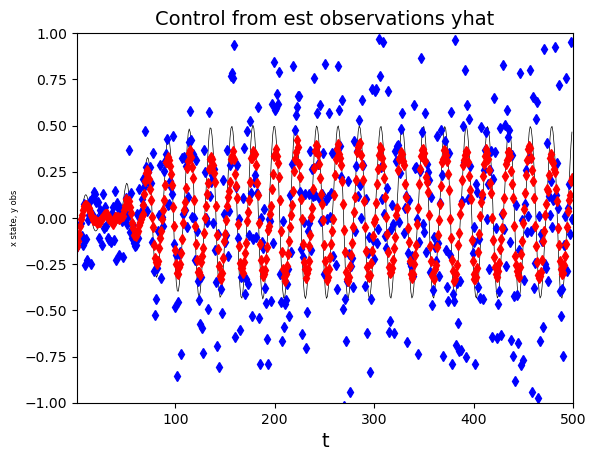

In [7]:
plotter(WC_88)

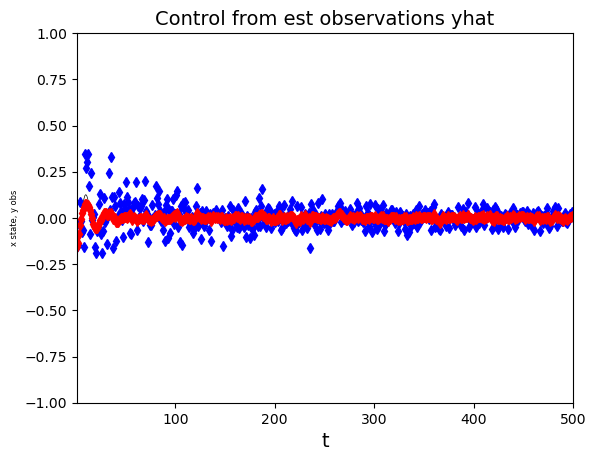

In [8]:
plotter(WC_66)

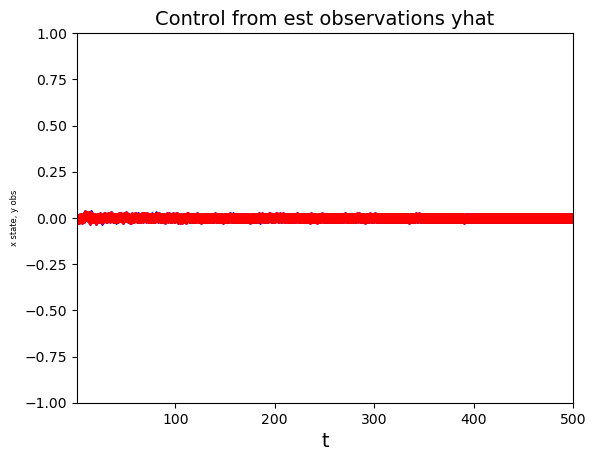

In [23]:
plotter(WC_66_2)

In [24]:
@widgets.interact(i=(0,WC_88.N-1))
def img_render_88(i=0):
    plt.subplot(131)
    u_real= np.reshape(WC_88.x[WC_88.dq:WC_88.f * WC_88.g + WC_88.dq, i], (WC_88.f, WC_88.g))
    plt.imshow(u_real)
    plt.title('Real u', fontsize=6)
    plt.clim(0, WC_88.y.max()/2)
    plt.subplot(132)
    u = np.reshape(WC_88.y[:, i], (WC_88.f, WC_88.g))  # Display noisy observations
    plt.imshow(u)
    plt.title('Observed u', fontsize=6)
    plt.clim(0, WC_88.y.max()/2)
    #plt.axis([0, f, 0, g, -1.5, 1.5])
    plt.subplot(133)
    uhat = np.reshape(WC_88.xhat[WC_88.dq:WC_88.f * WC_88.g + WC_88.dq, i], (WC_88.f, WC_88.g))
    plt.imshow(uhat)
    plt.title('uhat', fontsize=6)
    plt.clim(0, WC_88.y.max()/2)
    #plt.axis([0, f, 0, g, -1.5, 1.5])

interactive(children=(IntSlider(value=0, description='i', max=499), Output()), _dom_classes=('widget-interact'…

In [10]:
@widgets.interact(i=(0,WC_66.N-1))
def img_render_66(i=0):
    plt.subplot(131)
    u_real= np.reshape(WC_66.x[WC_66.dq:WC_66.f * WC_66.g + WC_66.dq, i], (WC_66.f, WC_66.g))
    plt.imshow(u_real)
    plt.title('Real u', fontsize=6)
    plt.clim(0, WC_66.y.max()/2)
    plt.subplot(132)
    u = np.reshape(WC_66.y[:, i], (WC_66.f, WC_66.g))  # Display noisy observations
    plt.imshow(u)
    plt.title('Observed u', fontsize=6)
    plt.clim(0, WC_66.y.max()/2)
    #plt.axis([0, f, 0, g, -1.5, 1.5])
    plt.subplot(133)
    uhat = np.reshape(WC_66.xhat[WC_66.dq:WC_66.f * WC_66.g + WC_66.dq, i], (WC_66.f, WC_66.g))
    plt.imshow(uhat)
    plt.title('uhat', fontsize=6)
    plt.clim(0, WC_66.y.max()/2)
    #plt.axis([0, f, 0, g, -1.5, 1.5])

interactive(children=(IntSlider(value=0, description='i', max=499), Output()), _dom_classes=('widget-interact'…

In [25]:
@widgets.interact(i=(0,WC_66_2.N-1))
def img_render_66_2(i=0):
    plt.subplot(131)
    u_real= np.reshape(WC_66_2.x[WC_66_2.dq:WC_66_2.f * WC_66_2.g + WC_66_2.dq, i], (WC_66_2.f, WC_66_2.g))
    plt.imshow(u_real)
    plt.title('Real u', fontsize=6)
    plt.clim(0, WC_66_2.y.max()/2)
    plt.subplot(132)
    u = np.reshape(WC_66_2.y[:, i], (WC_66_2.f, WC_66_2.g))  # Display noisy observations
    plt.imshow(u)
    plt.title('Observed u', fontsize=6)
    plt.clim(0, WC_66_2.y.max()/2)
    #plt.axis([0, f, 0, g, -1.5, 1.5])
    plt.subplot(133)
    uhat = np.reshape(WC_66_2.xhat[WC_66_2.dq:WC_66_2.f * WC_66_2.g + WC_66_2.dq, i], (WC_66_2.f, WC_66_2.g))
    plt.imshow(uhat)
    plt.title('uhat', fontsize=6)
    plt.clim(0, WC_66_2.y.max()/2)
    #plt.axis([0, f, 0, g, -1.5, 1.5])

interactive(children=(IntSlider(value=0, description='i', max=499), Output()), _dom_classes=('widget-interact'…

## 3.

_This Pinto-Ermentrout (modified Wilson-Cowan) system has a large repertoire of dynamical behaviors. The initial conditions and parameters used in the Assignment6.ipynb notebook produce rotating waves for example, but that’s only one possibility. Experiment with different initial conditions and look for stationary waves, linearly propagating waves, waves propagating from one point and so on. First try things out in the code from the Assignment6.ipynb notebook, which does not estimate the Kalman filter so runs faster. When you get something interesting try to apply the Kalman Filter and see if you get it to work. Give at least 3 examples (20 points). Some hints:_ 

a. Use uniform vs. non uniform initial conditions. 

b. Create initial conditions using for example 1-D vs 2-D gaussian blobs 

c. Try initial conditions with stripes 

d. You have to specify both u and a initial conditions. In the given initial conditions u and a are shifted with respect to one another. What are the consequences of that? Experiment with conditions in which u and are proportional to one another, and situations in which they are not.

## 4. 

_Apply control! Reproduce figure 3 and 4 of the Sauer and Schiff 2008 paper (20 points)_

## 5.

_NCE exercise 6.3 (Replace Wilson-Cowan equations with Fitzhugh-Nagumo) (10 points)_

_So can you substitute Fitzhugh-Nagumo dynamics forWilson-Cowan in the preceding
example? It is really a replacement of the dynamics at each node in the network—all the
rest stays the same. The parameters are different._

_• Hint: Try setting global variables to_

_global A B C f g dt K k nn and use parameter settings as_

_K = 1.38;A = 0.7;B = 0.8;C = 3; k = 0.91;_

_Later, we will explore using the one model to track a different (wrong) model. It is not that
unreasonable a suggestion. In real life, all of these models are wrong in that they do not
represent nature correctly, but that is a subject for a later chapter._